In [18]:
from skimage.io import imread
import os 
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks

In [41]:
dir = '../data/actin_kymo' 
listdir = os.listdir(dir)
tif_files = [f for f in listdir if f.endswith('tif')]

rep_nums = [int(f.split('_')[0][3:]) for f in tif_files]

# sort tif_files by rep_nums
tif_files = [x for _, x in sorted(zip(rep_nums, tif_files))]

print(tif_files)

['rep1_roi4_200px_wide_kymo.tif', 'rep2_roi4_200px_wide_kymo.tif', 'rep3_roi4_200px_wide_kymo.tif', 'rep4_roi4_200px_wide_kymo.tif', 'rep5_roi4_200px_wide_kymo.tif', 'rep6_roi4_200px_wide_kymo.tif', 'rep7_roi4_200px_wide_kymo.tif', 'rep8_roi4_200px_wide_kymo.tif', 'rep9_roi4_200px_wide_kymo.tif', 'rep10_roi4_200px_wide_kymo.tif', 'rep56_roi4_200px_wide_kymo.tif', 'rep67_roi4_200px_wide_kymo.tif', 'rep68_roi4_200px_wide_kymo.tif', 'rep72_roi4_200px_wide_kymo.tif', 'rep76_roi4_200px_wide_kymo.tif', 'rep77_roi4_200px_wide_kymo.tif', 'rep80_roi4_200px_wide_kymo.tif', 'rep81_roi4_200px_wide_kymo.tif', 'rep82_roi4_200px_wide_kymo.tif', 'rep83_roi4_200px_wide_kymo.tif', 'rep84_roi4_200px_wide_kymo.tif', 'rep87_roi4_200px_wide_kymo.tif', 'rep88_roi4_200px_wide_kymo.tif', 'rep96_roi4_200px_wide_kymo.tif', 'rep97_roi4_200px_wide_kymo.tif', 'rep103_roi4_200px_wide_kymo.tif', 'rep105_roi4_200px_wide_kymo.tif']


In [65]:
def compute_depletion_widths(density, axis, window=(20, 50), band=2, frac=0.8, prominence=0.05, ref=None):
    lo, hi = window
    idx = np.arange(len(density))
    in_window = (idx >= lo) & (idx < hi)

    # bulk reference level (pre-fraction); defaults to the mean of the two
    # profile edges, but can be set manually via `ref`.
    if ref is None:
        ref = (density[0] + density[-1]) / 2
    threshold = ref * frac

    # cable center = highest sufficiently-prominent peak INSIDE the window
    seg = density[lo:hi]
    peaks, _ = find_peaks(seg, prominence=prominence)
    if len(peaks) > 0:
        center = lo + int(peaks[np.argmax(seg[peaks])])
    else:
        center = lo + int(np.argmax(seg))

    selection = (density < threshold) & (idx > 20) & (idx < 50)
    selection[center - band:center + band] = False   # exclude the central cable band

    width = np.sum(selection) / 2

    # --- diagnostic plot ---
    axis.plot(density)
    threshold_line = np.full(len(density), threshold)
    threshold_masked = np.ma.masked_where(~selection, threshold_line)
    axis.plot(threshold_masked, 'r--', linewidth=1)
    axis.axvspan(center - band, center - 1 + band, alpha=0.2, color='tab:orange')
    axis.set_ylim([0, None])

    return width

(299, 1020)
(299, 68)
(20, 50)


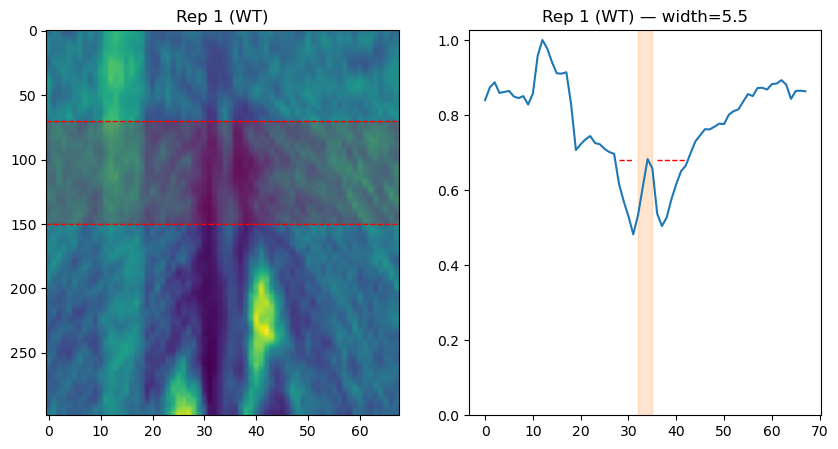

(299, 1020)
(299, 68)
(20, 50)


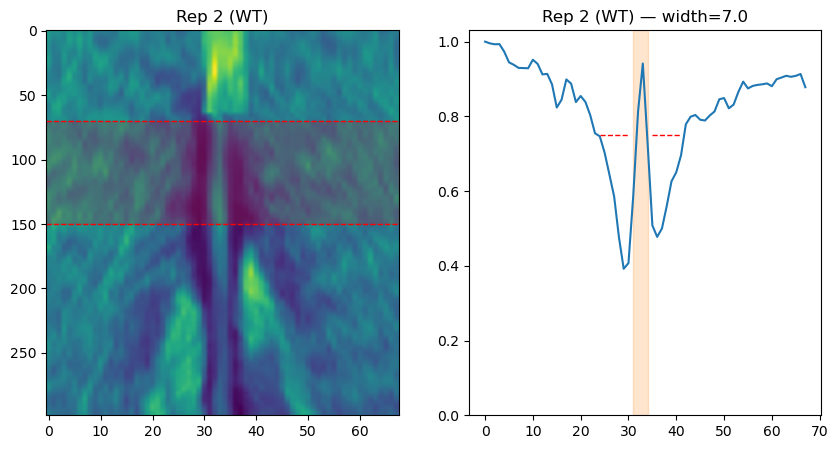

(299, 1020)
(299, 68)
(20, 50)


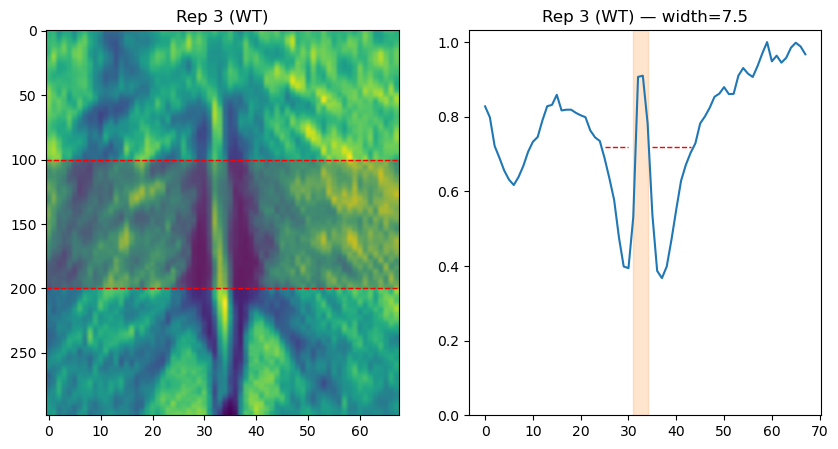

(299, 1020)
(299, 68)
(20, 50)


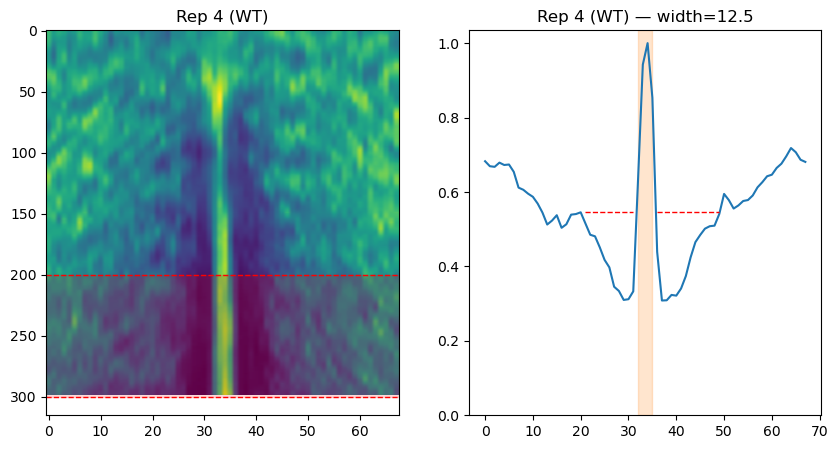

(299, 1020)
(299, 68)
(20, 50)


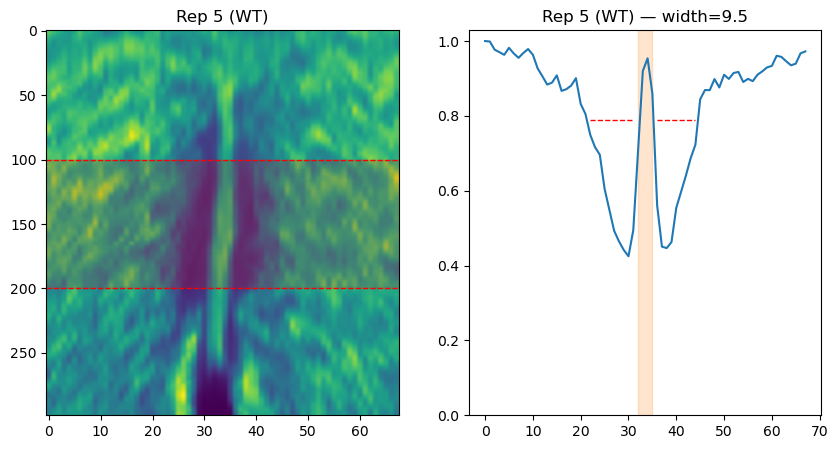

(299, 1020)
(299, 68)
(20, 50)


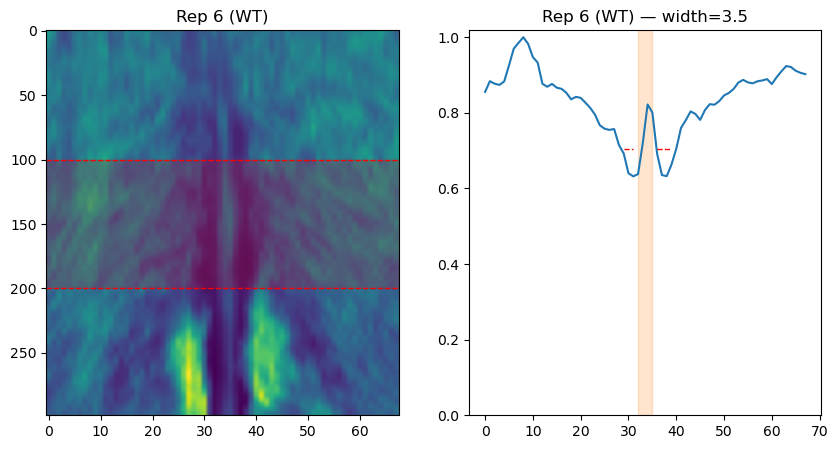

(299, 1020)
(299, 68)
(20, 50)


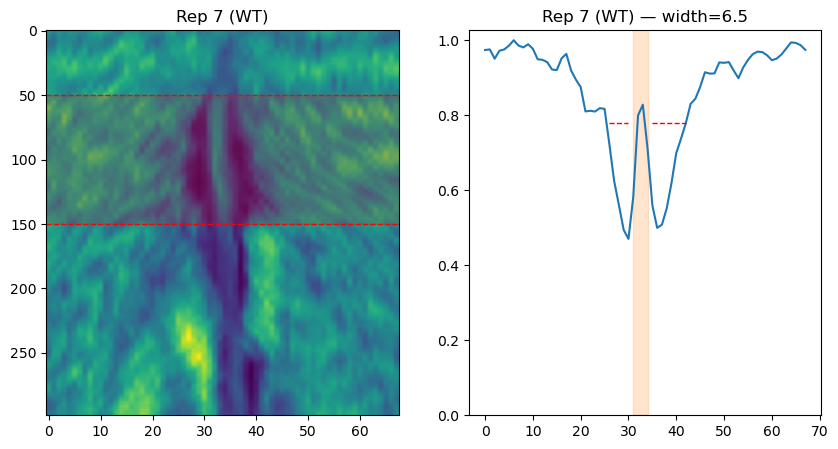

(299, 1020)
(299, 68)
(20, 50)


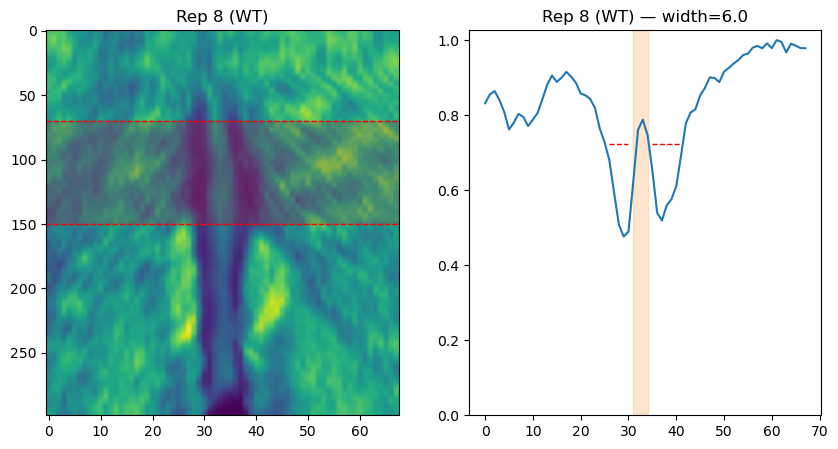

(299, 1020)
(299, 68)
(20, 50)


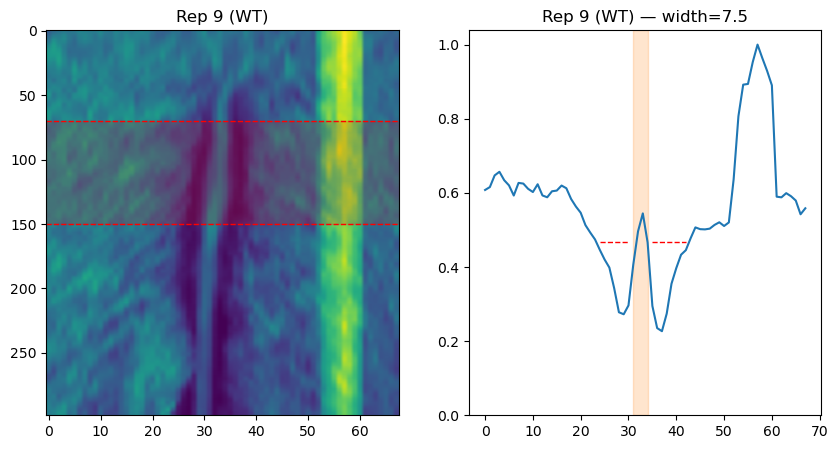

(299, 1020)
(299, 68)
(20, 50)


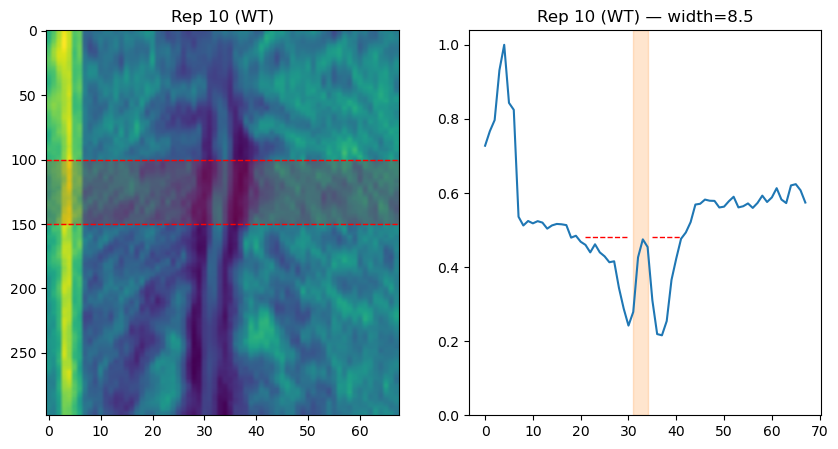

(488, 1020)
(488, 68)
(25, 40)


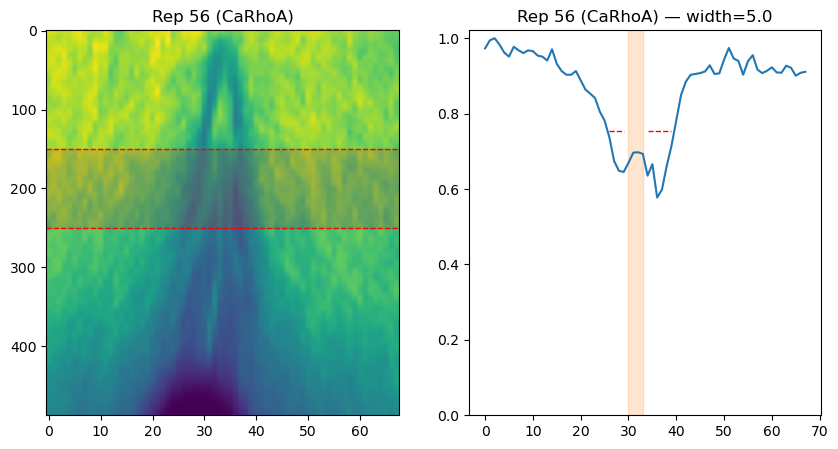

(955, 1020)
(955, 68)
(30, 35)


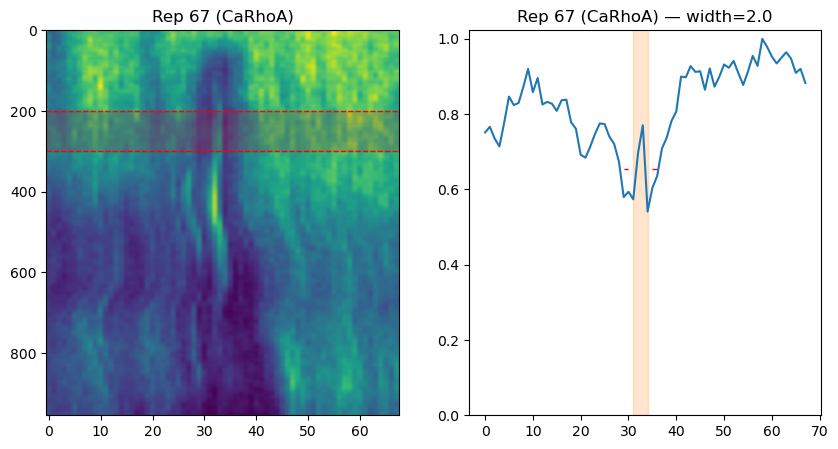

(677, 1020)
(677, 68)
(25, 40)


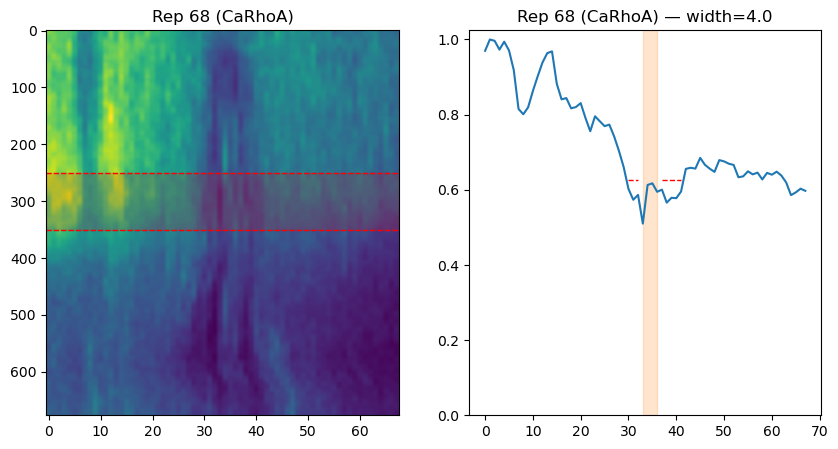

(488, 1020)
(488, 68)
(20, 50)


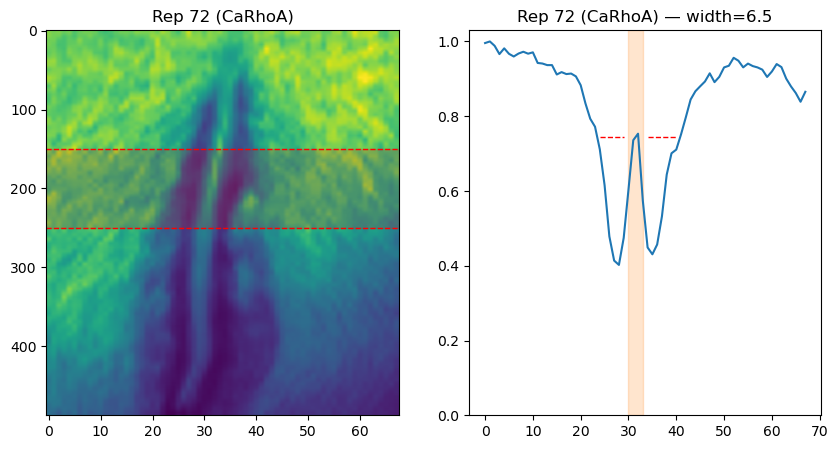

(777, 1020)
(777, 68)
(25, 35)


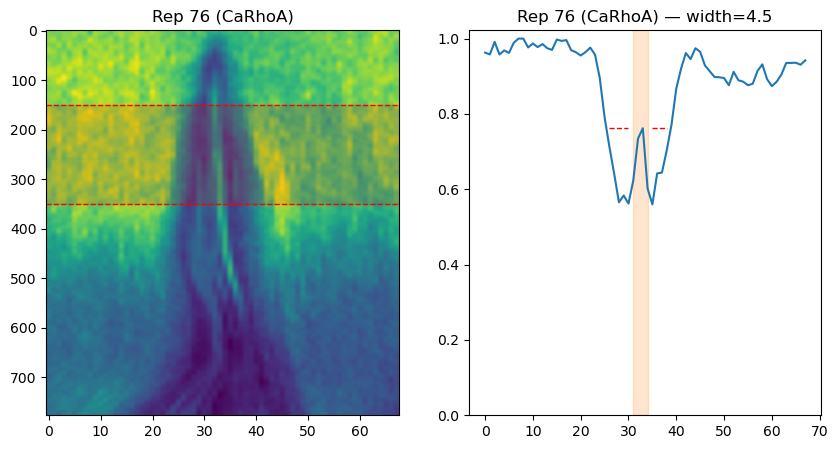

(435, 1020)
(435, 68)
(20, 50)


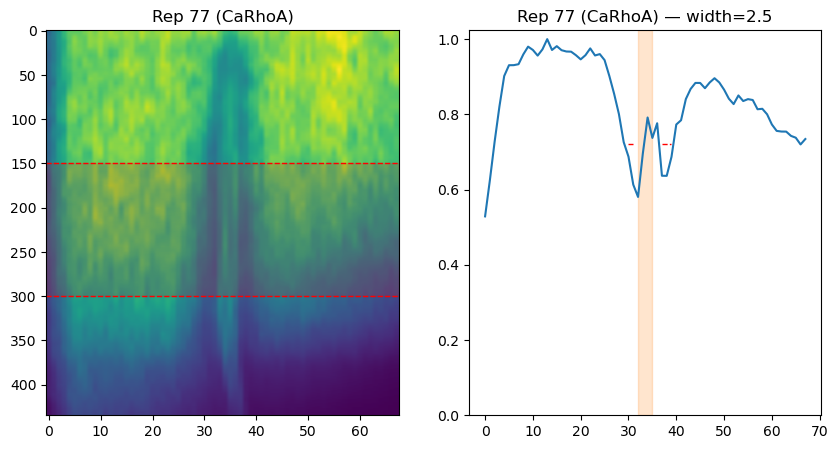

(619, 1020)
(619, 68)
(20, 50)


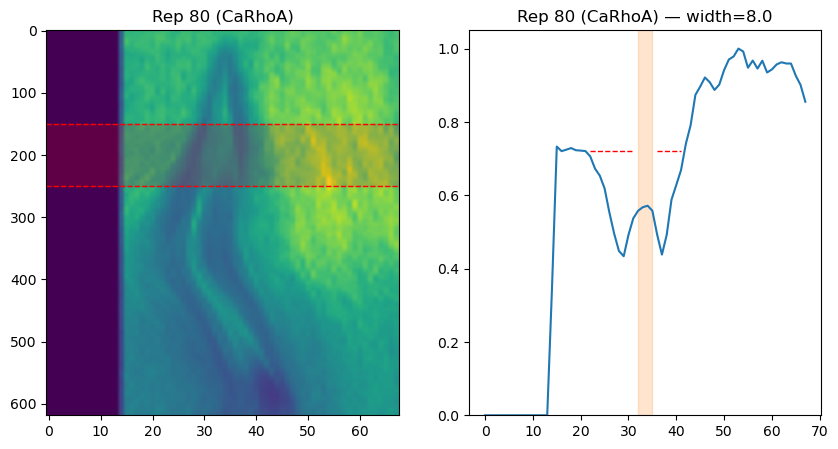

(934, 1020)
(934, 68)
(25, 40)


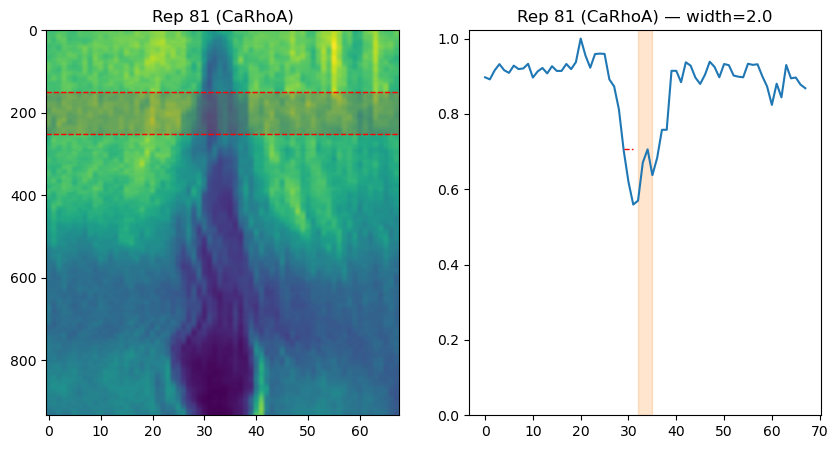

(378, 1020)
(378, 68)
(20, 50)


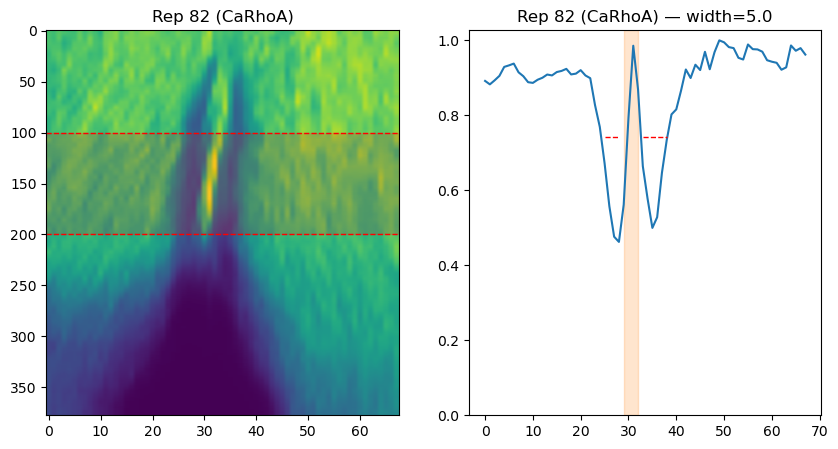

(918, 1020)
(918, 68)
(28, 32)


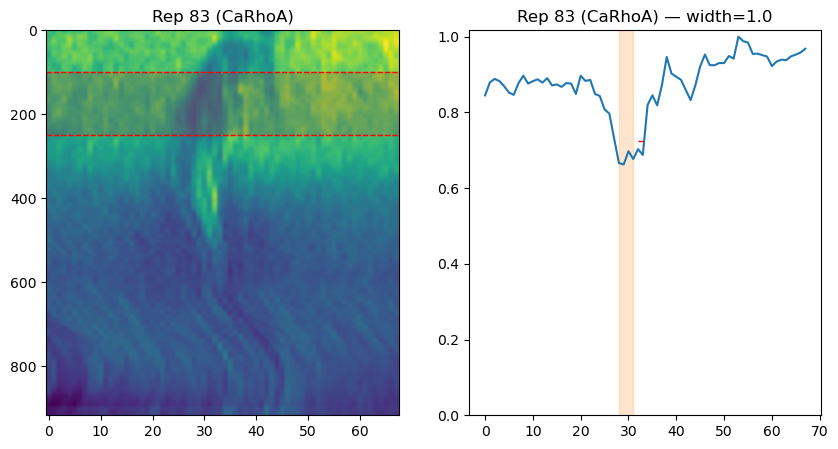

(391, 1020)
(391, 68)
(35, 45)


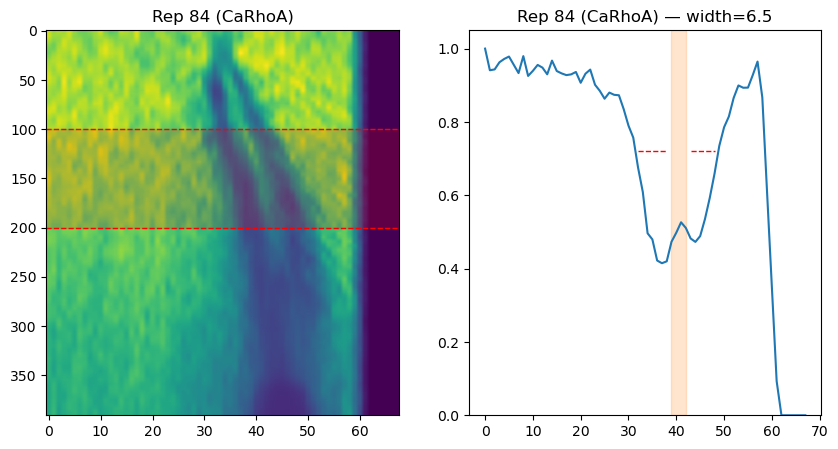

(544, 1020)
(544, 68)
(25, 30)


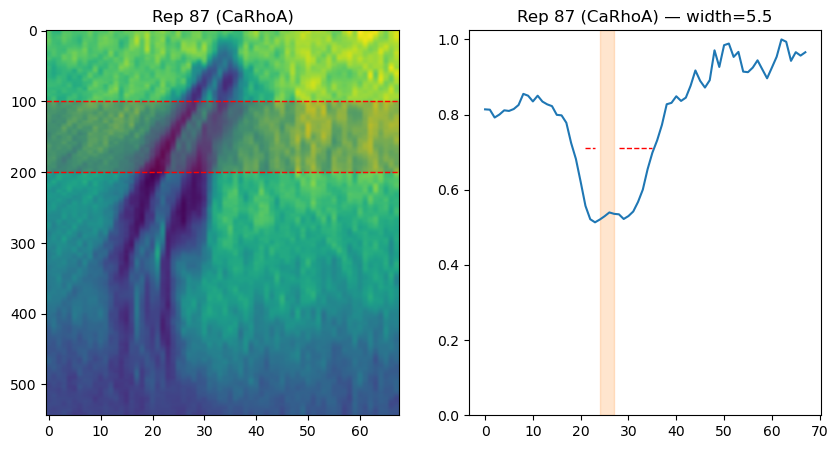

(392, 1020)
(392, 68)
(35, 45)


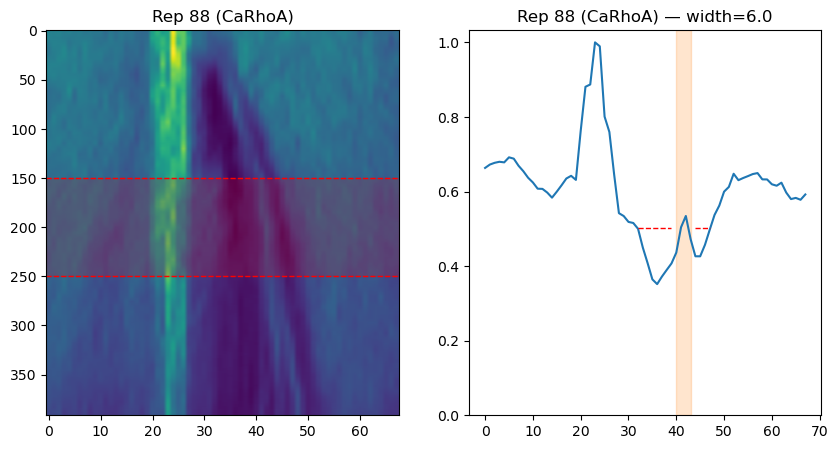

(484, 1020)
(484, 68)
(20, 50)


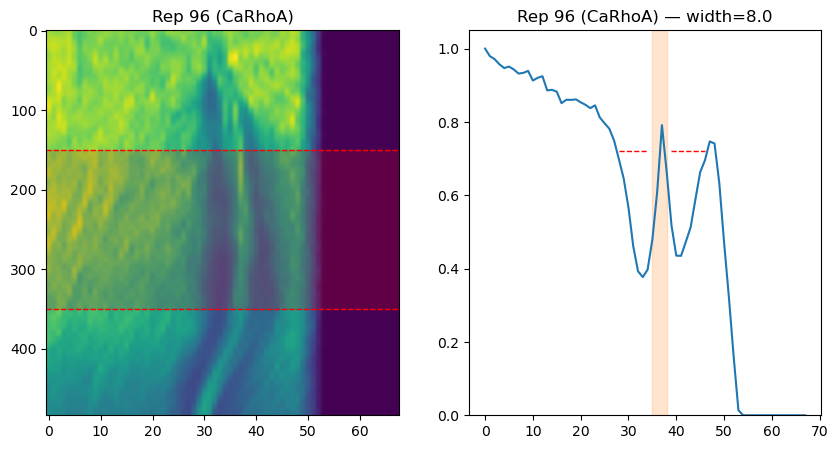

(493, 1020)
(493, 68)
(20, 50)


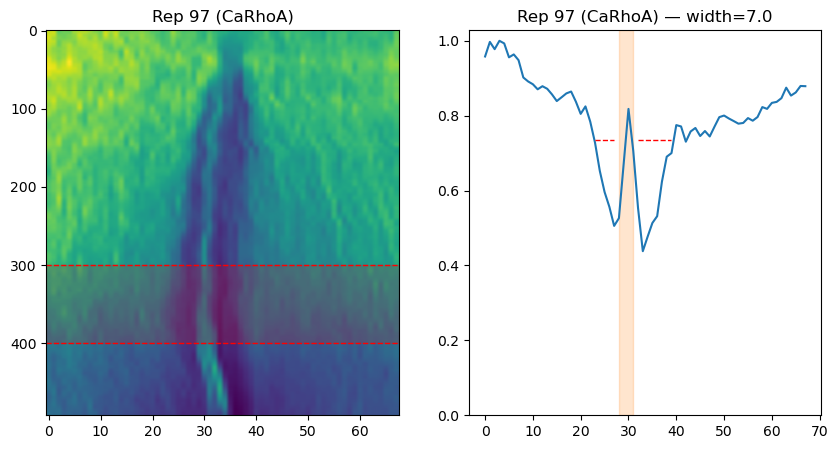

(761, 1020)
(761, 68)
(30, 40)


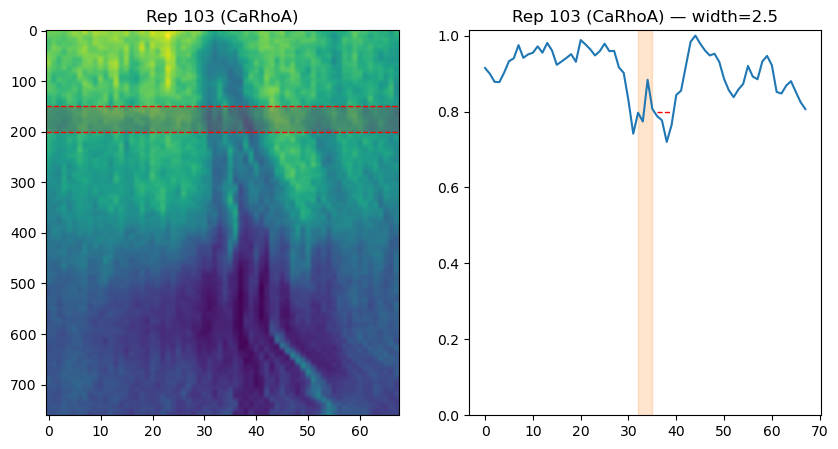

(551, 1020)
(551, 68)
(20, 50)


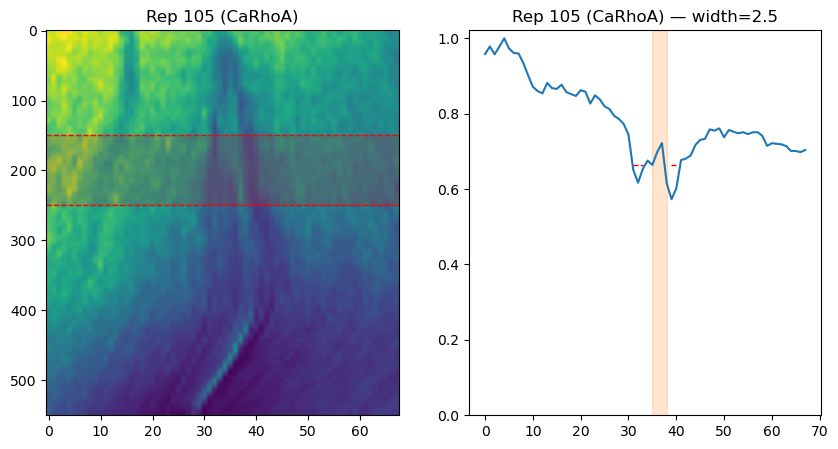

In [66]:
# `ranges`: per-rep VERTICAL (time) window of the kymograph to average over.
ranges = [(70, 150), (70, 150), (100, 200), (200, 300), (100, 200), 
          (100, 200), (50, 150), (70, 150), (70, 150), (100, 150), 
          (150, 250), (200, 300), (250, 350), (150, 250), (150, 350), (150, 300), (150, 250), 
          (150, 250), (100, 200), (100, 250), (100, 200), (100, 200), (150, 250), 
          (150, 350), (300, 400), (150, 200), (150, 250)]

# reps with no measurable furrow -> width = 0
# excludes = [68, 81, 83, 84, 88, 105]
excludes = [] 

# reps 1-10 are wild-type; everything else is CaRhoA
WT_keys = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

# Per-rep HORIZONTAL window override (lo, hi) for samples where the furrow sits
# outside the default. Falls back to the default for reps not listed.
window_overrides = {
    56: (25, 40),
    67: (30, 35), 
    68: (25, 40),
    76: (25, 35), 
    81: (25, 40), 
    83: (28, 32), 
    84: (35, 45), 
    87: (25, 30), 
    88: (35, 45), 
    103: (30, 40)
}
default_window = (20, 50)

# Per-rep pre-fraction reference level (the value multiplied by `frac`).
# Falls back to the edge-average baseline for reps not listed.
ref_overrides = {
    10: 0.6, 
    77: 0.9, 
    80: 0.9, 
    84: 0.9, 
    96: 0.9, 
    103: 1.0
}

furrow_widths = {}

for tif, (start, end) in zip(tif_files, ranges):
    rep_num = int(tif.split('_')[0][3:])
    genotype = 'WT' if rep_num in WT_keys else 'CaRhoA'

    if rep_num in excludes:
        print(rep_num, 'excluded')
        furrow_widths[rep_num] = 0
        continue
    img = imread(os.path.join(dir, tif))

    # average over every 15 columns

    dim2 = img.shape[1] // 15 * 15
    img = img[:, :dim2]

    print(img.shape) 
    img_reshaped = img.reshape(img.shape[0], -1, 15)
    img_avg = img_reshaped.mean(axis=2)
    print(img_avg.shape)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(img_avg, aspect='auto')
    axes[0].set_title(f'Rep {rep_num} ({genotype})')
    # highlight the time range that is averaged into the density profile
    axes[0].axhspan(start, end, color='red', alpha=0.15)
    axes[0].axhline(start, color='red', linestyle='--', linewidth=1)
    axes[0].axhline(end, color='red', linestyle='--', linewidth=1)

    mean_density = img_avg[start:end, :].mean(axis=0)/img_avg[start:end, :].mean(axis=0).max()
    window = window_overrides.get(rep_num, default_window)
    print(window)
    width = compute_depletion_widths(mean_density, axes[1], window=window, ref=ref_overrides.get(rep_num))
    axes[1].set_title(f'Rep {rep_num} ({genotype}) — width={width:.1f}')
    furrow_widths[rep_num] = width 
    plt.show() 

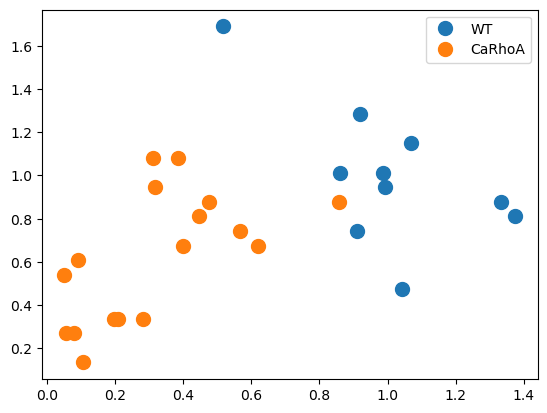

In [63]:
velocity_dic = { 
1	:4.006984421,
2	:4.373186761,
3	:3.792165342,
4	:2.272906508,
5	:4.053958683,
6	:4.593747355,
7	:5.874932102,
8	:6.063520589,
9	:4.350455061,
10	:4.706483501,
56	:1.763044973,
67	:0.341262915,
68	:0.222373193,
72	:3.78553019,
76	:0.393564151,
77	:0.861978169,
80	:1.365524839,
81	:0.248005656,
82	:2.728142273,
83	:0.469032564,
84	:2.096262202,
87	:2.491341296,
88	:1.971742614,
96	:1.69989256,
97	:1.402504482,
103	:0.913830829,
105	:1.236942175,
}

res = np.load('sim_data/caRhoA.npz')
velocities = res['velocities']
widths = res['widths']


WT_keys = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

v_WT_mean = np.mean([velocity_dic[k] for k in WT_keys])
dz_w_WT_mean = np.mean([furrow_widths[k] for k in WT_keys])

v_WT = np.array([velocity_dic[k] for k in WT_keys])/v_WT_mean
v_CaRhoA = np.array([velocity_dic[k] for k in velocity_dic.keys() if k not in WT_keys])/v_WT_mean

dz_WT = np.array([furrow_widths[k] for k in WT_keys])/dz_w_WT_mean
dz_CaRhoA = np.array([furrow_widths[k] for k in velocity_dic.keys() if k not in WT_keys])/dz_w_WT_mean


plt.plot(v_WT, dz_WT, 'o', markersize=10, label='WT')
plt.plot(v_CaRhoA, dz_CaRhoA, 'o', markersize=10, label='CaRhoA')
# plt.plot(velocities, widths, '--', linewidth=2, label='Simulation')
plt.legend()
plt.show()

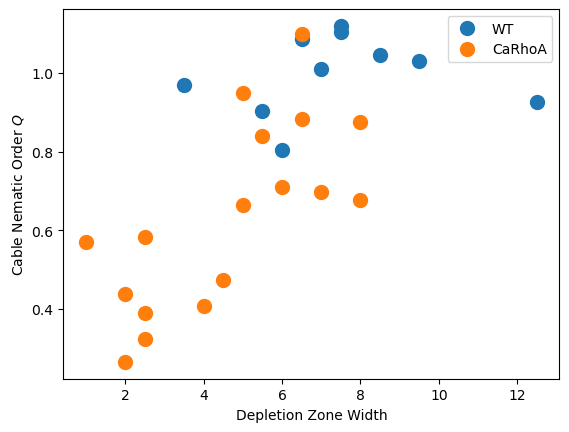

In [67]:
# Cable nematic order (Q) vs depletion-zone width.

Q = np.load(os.path.join(dir, 'cable_nematic_order_wt_vs_carhoa.npz'))
Q_WT = Q['wt']
Q_CaRhoA = Q['carhoa']

CaRhoA_keys = [k for k in velocity_dic.keys() if k not in WT_keys]
w_WT = np.array([furrow_widths[k] for k in WT_keys])
w_CaRhoA = np.array([furrow_widths[k] for k in CaRhoA_keys])

plt.plot(w_WT, Q_WT, 'o', markersize=10, label='WT')
plt.plot(w_CaRhoA, Q_CaRhoA, 'o', markersize=10, label='CaRhoA')
plt.xlabel('Depletion Zone Width')
plt.ylabel('Cable Nematic Order $Q$')
plt.legend()
plt.show()

In [68]:
np.savez('sim_data/furrow_width_data.npz', v_WT=v_WT, v_CaRhoA=v_CaRhoA, dz_WT=dz_WT, dz_CaRhoA=dz_CaRhoA, 
         Q_WT = Q_WT, Q_CaRhoA = Q_CaRhoA)